# Etape 1 : Préparation des données

## Imports et variables

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

app_train = pd.read_csv('../data_csv/application_train.csv')
app_test = pd.read_csv('../data_csv/application_test.csv')
bureau = pd.read_csv('../data_csv/bureau.csv')
bureau_balance = pd.read_csv('../data_csv/bureau_balance.csv')
prev_app = pd.read_csv('../data_csv/previous_application.csv')
pos_cash = pd.read_csv('../data_csv/POS_CASH_balance.csv')
credit_card = pd.read_csv('../data_csv/credit_card_balance.csv')
installments = pd.read_csv('../data_csv/installments_payments.csv')

print('df shapes:\n')
for name, df in [('app_train', app_train), ('app_test', app_test), ('bureau', bureau), ('bureau_balance', bureau_balance), ('prev_app', prev_app), ('pos_cash', pos_cash), ('credit_card', credit_card), ('installments', installments)]:
    print(f'{name:} : {df.shape}')

df shapes:

app_train : (307511, 122)
app_test : (48744, 121)
bureau : (1716428, 17)
bureau_balance : (27299925, 3)
prev_app : (1670214, 37)
pos_cash : (10001358, 8)
credit_card : (3840312, 23)
installments : (13605401, 8)


## Analyse exploratoire

### Suppression de features non utiles :

- `FLAG_MOBIL`: "Did client provide mobile phone"
- `FLAG_DOCUMENT_2` à `FLAG_DOCUMENT_21` : "Did client provide document x..."
- Colonnes bâtiment (`APARTMENTS_*`, `BASEMENTAREA_*`, `FLOORSMAX_*`, etc.) : infos sur le logement du client
- `WEEKDAY_APPR_PROCESS_START`, `HOUR_APPR_PROCESS_START` :"On which day of the week/hour did the client apply for the loan"
- `NAME_TYPE_SUITE` : "Who was accompanying client when he was applying for the loan""
- `CREDIT_CURRENCY`
- `RATE_INTEREST_PRIMARY/PRIVILEGED` : trop de NaN
- `FLAG_LAST_APPL_PER_CONTRACT`, `NFLAG_LAST_APPL_IN_DAY`
- Colonnes détail tirages carte (`AMT_DRAWINGS_ATM`, `CNT_DRAWINGS`)

In [20]:
COLS_TO_DROP_APP = ['FLAG_MOBIL','FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17','FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21','APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG','COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG','LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE','COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE','LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI','COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI','LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI','FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START','NAME_TYPE_SUITE']
app_train = app_train.drop(columns=COLS_TO_DROP_APP, errors='ignore')
app_test = app_test.drop(columns=COLS_TO_DROP_APP, errors='ignore')

# bureau
COLS_TO_DROP_BUREAU = ['CREDIT_CURRENCY', 'AMT_CREDIT_SUM_LIMIT']
bureau = bureau.drop(columns=COLS_TO_DROP_BUREAU, errors='ignore')

# previous_application
COLS_TO_DROP_PREV = ['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED','WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START','FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'NAME_TYPE_SUITE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY']
prev_app = prev_app.drop(columns=COLS_TO_DROP_PREV, errors='ignore')

# credit_card_balance
COLS_TO_DROP_CC = ['AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT','CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT','AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE']
credit_card = credit_card.drop(columns=COLS_TO_DROP_CC, errors='ignore')

In [21]:
print('df shapes:\n')
for name, df in [('app_train', app_train), ('app_test', app_test), ('bureau', bureau), ('bureau_balance', bureau_balance), ('prev_app', prev_app), ('pos_cash', pos_cash), ('credit_card', credit_card), ('installments', installments)]:
    print(f'{name:} : {df.shape}')

df shapes:

app_train : (307511, 51)
app_test : (48744, 50)
bureau : (1716428, 15)
bureau_balance : (27299925, 3)
prev_app : (1670214, 28)
pos_cash : (10001358, 8)
credit_card : (3840312, 15)
installments : (13605401, 8)


### Distribution target

TARGET
0    282686
1     24825
Name: count, dtype: int64
Taux de non remboursement : 8.1%


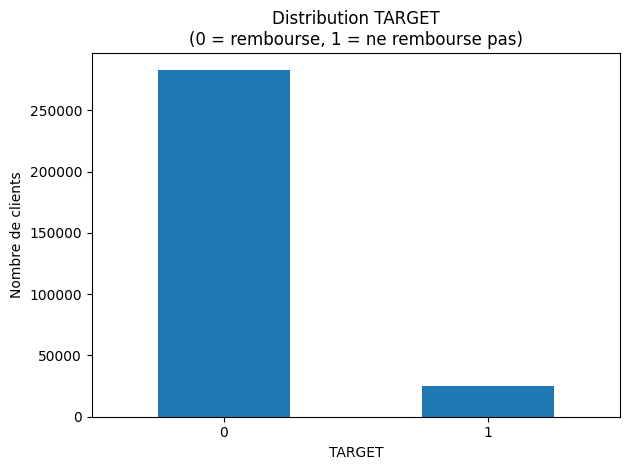

In [22]:
print(app_train['TARGET'].value_counts())
print(f'Taux de non remboursement : {app_train["TARGET"].mean()*100:.1f}%')

app_train['TARGET'].value_counts().plot(kind='bar')
plt.title('Distribution TARGET\n(0 = rembourse, 1 = ne rembourse pas)')
plt.xlabel('TARGET'); plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

- dataset déséquilibré : plus d'individus qui remboursent que de personnes qui ne remboursent pas.
- Environ 92% remboursent et 8% remboursent pas.

### Valeurs manquantes

In [23]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_pct = 100 * mis_val / len(df)
    table = pd.concat([mis_val, mis_val_pct], axis=1)
    table.columns = ['NaN', '% proportion']
    table = table[table['NaN'] > 0].sort_values('% proportion', ascending=False).round(1)
    print(f'{len(table)} colonnes avec NaN')
    return table

missing = missing_values_table(app_train)
print(missing.head(20).to_string())

19 colonnes avec NaN
                               NaN  % proportion
OWN_CAR_AGE                 202929          66.0
EXT_SOURCE_1                173378          56.4
OCCUPATION_TYPE              96391          31.3
EXT_SOURCE_3                 60965          19.8
AMT_REQ_CREDIT_BUREAU_MON    41519          13.5
AMT_REQ_CREDIT_BUREAU_YEAR   41519          13.5
AMT_REQ_CREDIT_BUREAU_QRT    41519          13.5
AMT_REQ_CREDIT_BUREAU_WEEK   41519          13.5
AMT_REQ_CREDIT_BUREAU_DAY    41519          13.5
AMT_REQ_CREDIT_BUREAU_HOUR   41519          13.5
OBS_30_CNT_SOCIAL_CIRCLE      1021           0.3
DEF_60_CNT_SOCIAL_CIRCLE      1021           0.3
DEF_30_CNT_SOCIAL_CIRCLE      1021           0.3
OBS_60_CNT_SOCIAL_CIRCLE      1021           0.3
EXT_SOURCE_2                   660           0.2
AMT_GOODS_PRICE                278           0.1
AMT_ANNUITY                     12           0.0
CNT_FAM_MEMBERS                  2           0.0
DAYS_LAST_PHONE_CHANGE           1           0.0

### Types des features

In [24]:
print(app_train.dtypes.value_counts())

float64    22
int64      19
object     10
Name: count, dtype: int64


10 colonnes  `object` : il faudra les encoder avant la modélisation

### Anomalie DAYS_EMPLOYED

In [25]:
# 55 000 clients ont pour nombre de jours d'emploi = 365243 = environ 1000 ans
# Valeur 365243 = anomalie
print(app_train['DAYS_EMPLOYED'].describe())

anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print(f'Clients NON anomalies qui ne remboursent pas : {non_anom["TARGET"].mean()*100:.2f}%')
print(f'Clients anomalies qui ne remboursent pas: {anom["TARGET"].mean()*100:.2f}%')
print(f"Nombre d'anomalies : {len(anom)}")

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64
Clients NON anomalies qui ne remboursent pas : 8.66%
Clients anomalies qui ne remboursent pas: 5.40%
Nombre d'anomalies : 55374


### Age x remboursement

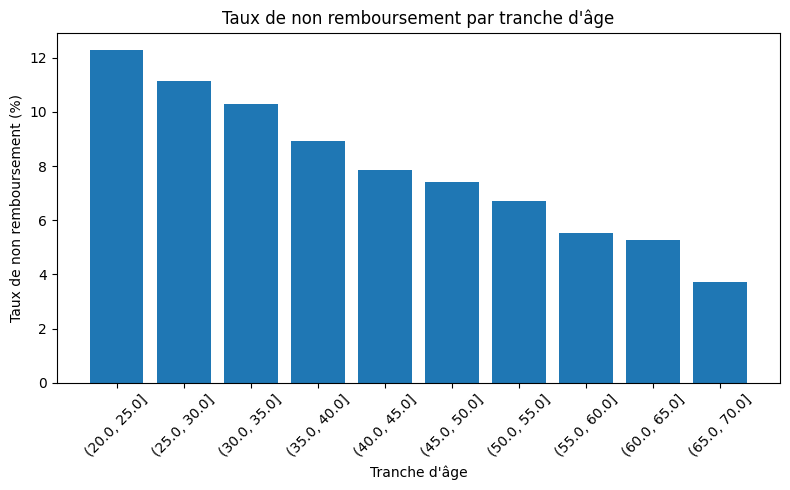

In [26]:
age_data = app_train[['TARGET', 'DAYS_BIRTH']].copy()
age_data['YEARS_BIRTH']  = age_data['DAYS_BIRTH'].abs() / 365
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins=np.linspace(20, 70, 11))

age_groups = age_data.groupby('YEARS_BINNED')['TARGET'].mean()

plt.figure(figsize=(8, 5))
plt.bar(age_groups.index.astype(str), 100 * age_groups)
plt.xticks(rotation=45); plt.xlabel("Tranche d'âge")
plt.ylabel('Taux de non remboursement (%)'); plt.title('Taux de non remboursement par tranche d\'âge')
plt.tight_layout(); plt.show()

### Variables EXT_SOURCE

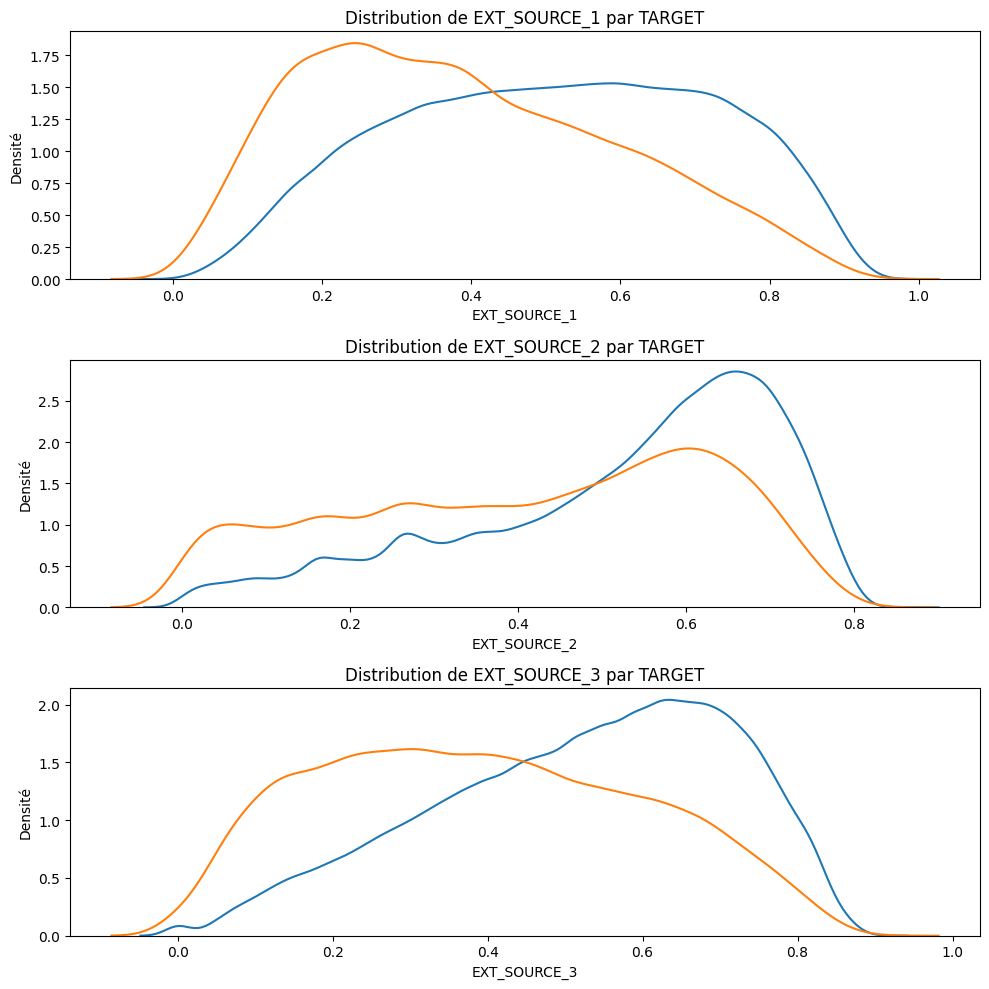

In [27]:
# EXT_SOURCE (variables les plus corrélées avec la target)
plt.figure(figsize=(10, 10))
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(3, 1, i + 1)
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label='Rembourse (0)')
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label='Défaut (1)')
    plt.title(f'Distribution de {source} par TARGET')
    plt.xlabel(source); plt.ylabel('Densité')
plt.tight_layout(); plt.show()

## Nettoyage

In [28]:
def clean_application(df):
    df = df.copy()

    #Anomalie DAYS_EMPLOYED : nouvelle colonne + remplacement valeur par NaN
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # Valeur aberrante CODE_GENDER 'XNA' remplacée en NaN
    df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)

    # création 4 features métier
    df['CREDIT_INCOME_PERCENT']  = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']  # the percentage of the credit amount relative to a client's income
    df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']  # mthe percentage of the loan annuity amount relative to a client's income
    df['CREDIT_TERM'] = df['AMT_ANNUITY']  / df['AMT_CREDIT'] # the length of the payment in months 
    df['DAYS_EMPLOYED_PERCENT']  = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH'].abs() # the percentage of the days employed relative to the client's age

    return df

app_train = clean_application(app_train)
app_test  = clean_application(app_test)

## Encoding

In [29]:
#Encodage des variables catégorielles

# Label Encoding pour les variables avec 2 catégories: on encode en 0/1
le = LabelEncoder()
le_count = 0
for col in app_train.select_dtypes('object').columns:
    if app_train[col].nunique() <= 2:
        le.fit(app_train[col].dropna())
        app_train[col] = app_train[col].map(lambda x: le.transform([x])[0] if pd.notna(x) else np.nan)
        app_test[col]  = app_test[col].map(lambda x: le.transform([x])[0] if pd.notna(x) else np.nan)
        le_count += 1

# One-Hot Encoding pour le reste: on crée une colonne binaire par catégorie
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

# alignement train/test : on garde uniquement les colonnes communes aux deux
train_labels = app_train['TARGET']
app_train, app_test = app_train.align(app_test, join='inner', axis=1)
app_train['TARGET'] = train_labels

print(f'train : {app_train.shape} test : {app_test.shape}')

train : (307511, 149) test : (48744, 148)


## Agrégation des DFs

In [30]:
# Les tables secondaires ont plusieurs lignes par client
# On résume l'historique de chaque client en une ligne avec des stats
def aggregate_num(df, group_key, prefix):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != group_key]
    agg = df.groupby(group_key)[num_cols].agg(['mean', 'sum'])
    agg.columns = [f'{prefix}_{col}_{stat}' for col, stat in agg.columns]
    return agg.reset_index()

# bureau_balance : 2 niveaux d'agrégation (mensuel → crédit → client)
# Encoder STATUS (catégoriel : C, X, 0-5)
bureau_balance = pd.get_dummies(bureau_balance, columns=['STATUS'], prefix='bureau_bal_status')
bureau_bal_agg = aggregate_num(bureau_balance, 'SK_ID_BUREAU', 'bbal')
bureau = bureau.merge(bureau_bal_agg, on='SK_ID_BUREAU', how='left')

# bureau : agréger par client par SK_ID_CURR
bureau = pd.get_dummies(bureau, columns=['CREDIT_ACTIVE', 'CREDIT_TYPE'])
bureau_agg = aggregate_num(bureau, 'SK_ID_CURR', 'bureau')

# previous_application : agréger par SK_ID_CURR
prev_app_cat_cols = ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START','FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE','NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON','NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']
prev_app_cat_cols = [c for c in prev_app_cat_cols if c in prev_app.columns]
prev_app_enc = pd.get_dummies(prev_app, columns=prev_app_cat_cols)
# Remplacer anomalie DAYS = 365243 par NaN
for col in ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']:
    if col in prev_app_enc.columns:
        prev_app_enc[col] = prev_app_enc[col].replace(365243, np.nan)
prev_app_agg = aggregate_num(prev_app_enc, 'SK_ID_CURR', 'prev')

# POS_CASH_balance : agréger par SK_ID_CURR
pos_cash_enc = pd.get_dummies(pos_cash, columns=['NAME_CONTRACT_STATUS'], prefix='pos_status')
pos_cash_agg = aggregate_num(pos_cash_enc, 'SK_ID_CURR', 'pos')

# credit_card_balance: agréger par SK_ID_CURR
cc_enc = pd.get_dummies(credit_card, columns=['NAME_CONTRACT_STATUS'], prefix='cc_status')
cc_agg = aggregate_num(cc_enc, 'SK_ID_CURR', 'cc')

# installments_payments : agréger par SK_ID_CURR
# 2 features métier : retard de paiement et écart par rapport au montant dû
installments['PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
installments['DAYS_LATE'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
inst_agg = aggregate_num(installments, 'SK_ID_CURR', 'inst')

print(f'train : {app_train.shape} test : {app_test.shape}')


train : (307511, 149) test : (48744, 148)


Le df "bureau" par ex a plusieurs lignes par client (un crédit passé = une ligne). On peut pas fusionner directement avec app_train qui n'a qu'une ligne par client. 

solution : résumer l'historique de chaque client en une seule ligne avec des stats (moyenne, somme, max, min, nombre). Par exemple pour un client avec 3 anciens crédits : montant moyen, montant total, etc.

## Fusion finale

In [31]:
def merge_all(main_df):
    df = main_df.copy()
    for agg_df, key in [
        (bureau_agg,'SK_ID_CURR'),
        (prev_app_agg, 'SK_ID_CURR'),
        (pos_cash_agg, 'SK_ID_CURR'),
        (cc_agg,  'SK_ID_CURR'),
        (inst_agg, 'SK_ID_CURR'),
    ]:
        df = df.merge(agg_df, on=key, how='left')
    return df

train = merge_all(app_train)
test = merge_all(app_test)

# Aligner à nouveau après fusion
target_col = train['TARGET']
train, test = train.align(test, join='inner', axis=1)
train['TARGET'] = target_col

print(f'NaN:')
missing_values_table(train)

NaN:
137 colonnes avec NaN


,NaN,% proportion
prev_DAYS_FIRST_DRAWING_mean,254159,82.7
cc_AMT_PAYMENT_CURRENT_mean,246451,80.1
bureau_AMT_ANNUITY_mean,227502,74.0
cc_AMT_PAYMENT_TOTAL_CURRENT_sum,220606,71.7
cc_MONTHS_BALANCE_sum,220606,71.7
...,...,...
ANNUITY_INCOME_PERCENT,12,0.0
CREDIT_TERM,12,0.0
CODE_GENDER,4,0.0
CNT_FAM_MEMBERS,2,0.0


## Feature engineering final

In [32]:
# isoler target et ids avant les transformations
target  = train['TARGET']
train_ids = train['SK_ID_CURR']
test_ids = test['SK_ID_CURR']

train = train.drop(columns=['TARGET', 'SK_ID_CURR'])
test = test.drop(columns=['SK_ID_CURR'])

# Suppression des colonnes avec + de 75% de NaN
SEUIL_NAN = 0.75
missing_pct = train.isnull().mean()
cols_a_supprimer = missing_pct[missing_pct > SEUIL_NAN].index.tolist()
train = train.drop(columns=cols_a_supprimer)
test  = test.drop(columns=cols_a_supprimer, errors='ignore')

# Imputation: on remplace les NaN restants par la médiane de chaque colonne
imputer = SimpleImputer(strategy='median')
train = pd.DataFrame(imputer.fit_transform(train), columns=train.columns)
test  = pd.DataFrame(imputer.transform(test),      columns=test.columns)

# Normalisation min-max : on ramène toutes les features entre 0 et 1
scaler = MinMaxScaler(feature_range=(0, 1))
train = pd.DataFrame(scaler.fit_transform(train), columns=train.columns)
test  = pd.DataFrame(scaler.transform(test),      columns=test.columns)

# On remet target et ids
train['TARGET'] = target.values
train['SK_ID_CURR'] = train_ids.values
test['SK_ID_CURR'] = test_ids.values

print(f'Shapes finales du train : {train.shape} et test : {test.shape}')

Shapes finales du train : (307511, 261) et test : (48744, 260)


In [21]:
sample_train = train.sample(frac=0.2, replace=True, random_state=1)
sample_test =test.sample(frac=0.2, replace=True, random_state=1)

In [22]:
print(f'shape train = {sample_train.shape}')
print(f'shape test = {sample_test.shape}')

shape train = (61502, 443)
shape test = (9749, 442)


## Sauvegarde

In [34]:
train.to_csv('../train_test/train_final.csv', index=False)
test.to_csv('../train_test/test_final.csv', index=False)

print(f'train_final.csv : {train.shape[0]} lignes, {train.shape[1]} colonnes')
print(f'test_final.csv: {test.shape[0]} lignes, {test.shape[1]} colonnes')

train_final.csv : 307511 lignes, 261 colonnes
test_final.csv: 48744 lignes, 260 colonnes
